<a href="https://colab.research.google.com/github/UConnARIAL/NRE5615_EnviroAI_Code_and_Data/blob/main/code/NRE5615_Wk7_Demo_NOAA_Temperature_Trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 Assignment Demo  
## Temperature Trends Using NOAA Climate Data

This notebook demonstrates a basic time-series workflow using NOAA Climate-at-a-Glance temperature departure data.



## Learning goals

By the end of this assignment, you should be able to:

1. Load and inspect temperature time-series data.
2. Explain what a temperature anomaly or departure from average means.
3. Identify time-series concepts such as trend, variability, anomaly, and forecasting.
4. Visualize temperature departures over time.
5. Aggregate monthly or 12-month period data to annual values.
6. Use a moving average to reduce short-term variability.
7. Fit a simple trend line.
8. Interpret the usefulness and limitations of simple AI/data-driven climate analysis for environmental decision-making.

## Important note about NOAA “Departure from Average”

In NOAA Climate-at-a-Glance, **Departure from Average** means the same thing as a temperature anomaly.

For this assignment:

```text
Departure from Average = temperature anomaly
```

NOAA file says:

```text
Units: Degrees Celsius
```

so the departure values are in degrees Celsius.

## Step 1: Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2: Load the NOAA data

The loader can handle:
- comment lines beginning with `#` given as meta infomation

In [9]:
url = "https://raw.githubusercontent.com/UConnARIAL/NRE5615_EnviroAI_Code_and_Data/main/data/Wk7_NOAA_Temperature_Anomaly.csv"

temp_df = pd.read_csv(url, comment="#")

temp_df.head()


,year,temperature_anomaly_c
0,1895,-0.23
1,1896,-0.13
2,1897,-0.12
3,1898,-0.26
4,1899,-0.17


## Step 3: Inspect the data

After loading, the notebook should produce a simplified annual table with:

- `year`
- `temperature_anomaly_c`

If the original NOAA file had monthly or 12-month-period rows, the notebook aggregates them to annual averages.

In [10]:
print("Rows and columns:", temp_df.shape)
print("Year range:", int(temp_df["year"].min()), "to", int(temp_df["year"].max()))
print("\nFirst rows:")
display(temp_df.head())

print("\nLast rows:")
display(temp_df.tail())

print("\nSummary:")
print(temp_df["temperature_anomaly_c"].describe())

Rows and columns: (131, 2)
Year range: 1895 to 2025

First rows:


,year,temperature_anomaly_c
0,1895,-0.23
1,1896,-0.13
2,1897,-0.12
3,1898,-0.26
4,1899,-0.17



Last rows:


,year,temperature_anomaly_c
126,2021,0.86
127,2022,0.90
128,2023,1.17
129,2024,1.26
130,2025,1.13



Summary:
count    131.00000
mean       0.14313
std        0.38626
min       -0.42000
25%       -0.13000
50%        0.04000
75%        0.36500
max        1.26000
Name: temperature_anomaly_c, dtype: float64


## Step 4: Plot the temperature anomaly time series

This plot shows annual temperature departures from average over time.

Look for:

- long-term trend,
- year-to-year variability,
- unusually warm or cool periods,
- recent changes compared with earlier years.

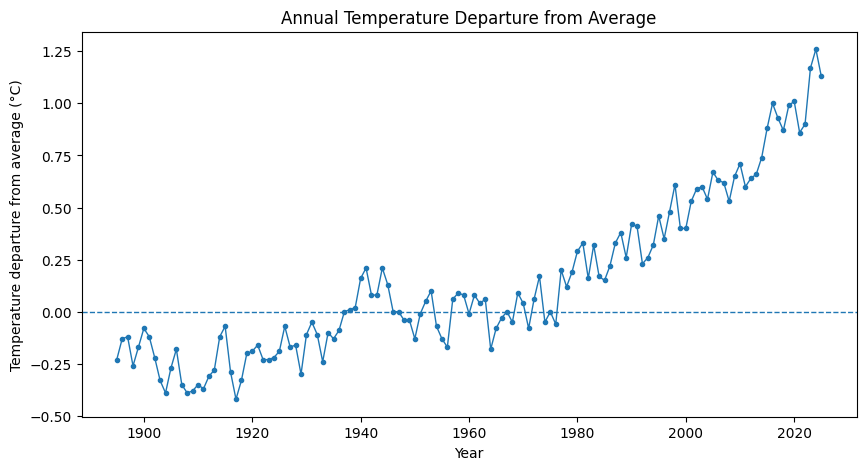

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(temp_df["year"], temp_df["temperature_anomaly_c"], marker="o", linewidth=1, markersize=3)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Temperature departure from average (°C)")
plt.title("Annual Temperature Departure from Average")
plt.show()

## Step 5: Add a moving average

A moving average smooths short-term variability so the longer-term pattern is easier to see.

Here we use a 10-year moving average.

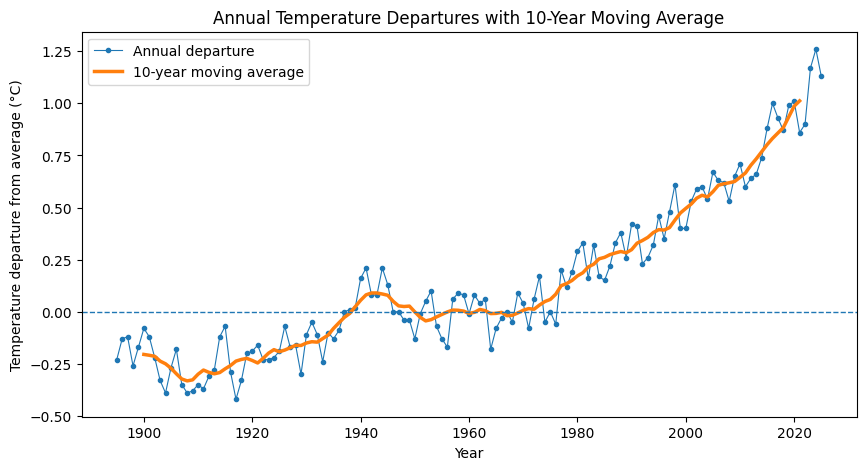

In [12]:
temp_df["moving_average_10yr"] = temp_df["temperature_anomaly_c"].rolling(window=10, center=True).mean()

plt.figure(figsize=(10, 5))
plt.plot(temp_df["year"], temp_df["temperature_anomaly_c"], marker="o", linewidth=0.8, markersize=3, label="Annual departure")
plt.plot(temp_df["year"], temp_df["moving_average_10yr"], linewidth=2.5, label="10-year moving average")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Temperature departure from average (°C)")
plt.title("Annual Temperature Departures with 10-Year Moving Average")
plt.legend()
plt.show()

## Step 6: Fit a simple trend line

This is a simple data-driven model using year to estimate temperature departure from average.

This is not a complete climate model. It is a basic way to summarize the direction and rate of change in a time series.

In [13]:
X = temp_df[["year"]]
y = temp_df["temperature_anomaly_c"]

trend_model = LinearRegression()
trend_model.fit(X, y)

temp_df["trend_line"] = trend_model.predict(X)

slope_per_year = trend_model.coef_[0]
slope_per_decade = slope_per_year * 10

print("Estimated trend:", round(slope_per_decade, 3), "°C per decade")
print("Intercept:", round(trend_model.intercept_, 3))

Estimated trend: 0.091 °C per decade
Intercept: -17.785


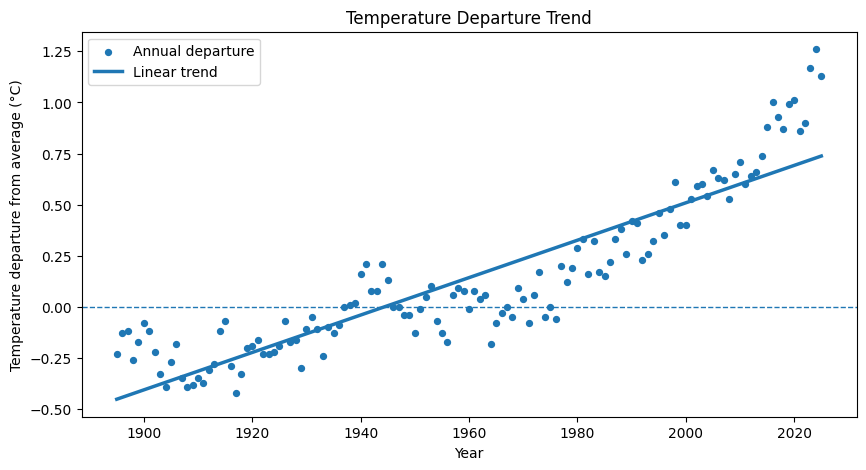

In [14]:
plt.figure(figsize=(10, 5))
plt.scatter(temp_df["year"], temp_df["temperature_anomaly_c"], s=18, label="Annual departure")
plt.plot(temp_df["year"], temp_df["trend_line"], linewidth=2.5, label="Linear trend")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Temperature departure from average (°C)")
plt.title("Temperature Departure Trend")
plt.legend()
plt.show()

## Step 7: Compare early and recent periods

Here we compare:

- the first 30 years in the dataset,
- the most recent 30 years in the dataset.

In [15]:
n_years = min(30, len(temp_df) // 3)

first_period = temp_df.head(n_years)
recent_period = temp_df.tail(n_years)

first_mean = first_period["temperature_anomaly_c"].mean()
recent_mean = recent_period["temperature_anomaly_c"].mean()
difference = recent_mean - first_mean

comparison = pd.DataFrame([
    {"Period": f"{int(first_period['year'].min())}-{int(first_period['year'].max())}", "Mean departure (°C)": first_mean},
    {"Period": f"{int(recent_period['year'].min())}-{int(recent_period['year'].max())}", "Mean departure (°C)": recent_mean},
    {"Period": "Difference", "Mean departure (°C)": difference}
])

comparison.round(3)

,Period,Mean departure (°C)
0,1895-1924,-0.246
1,1996-2025,0.732
2,Difference,0.978


## Step 8: Simple forecasting example

A linear model can be extended into the near future, but this should be interpreted carefully.

This is only a simple demonstration of forecasting logic. It does not include physical climate processes, uncertainty ranges, emissions scenarios, or climate model ensembles.

In [16]:
future_years = pd.DataFrame({"year": np.arange(int(temp_df["year"].max()) + 1, int(temp_df["year"].max()) + 11)})
future_years["forecast_anomaly_c"] = trend_model.predict(future_years[["year"]])

future_years.round(3)

,year,forecast_anomaly_c
0,2026,0.747
1,2027,0.756
2,2028,0.765
3,2029,0.774
4,2030,0.783
5,2031,0.793
6,2032,0.802
7,2033,0.811
8,2034,0.820
9,2035,0.829


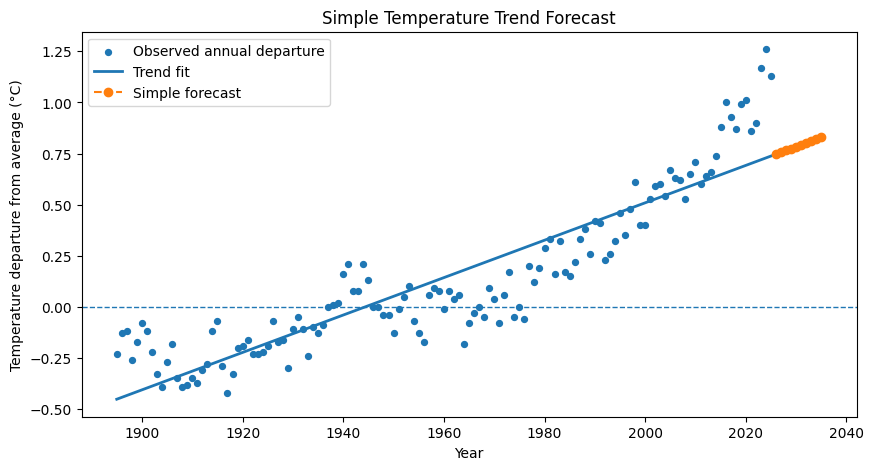

In [17]:
plt.figure(figsize=(10, 5))
plt.scatter(temp_df["year"], temp_df["temperature_anomaly_c"], s=18, label="Observed annual departure")
plt.plot(temp_df["year"], temp_df["trend_line"], linewidth=2, label="Trend fit")
plt.plot(future_years["year"], future_years["forecast_anomaly_c"], marker="o", linestyle="--", label="Simple forecast")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Temperature departure from average (°C)")
plt.title("Simple Temperature Trend Forecast")
plt.legend()
plt.show()

# Orange workflow notes

The same NOAA file can be used in Orange

## Basic Orange visualization workflow

`File → Data Table → Line Plot`

Use:
- x-axis: `year`
- y-axis: `temperature_anomaly_c`

You may also use:
`File → Scatter Plot`

Use:
- x-axis: `year`
- y-axis: `temperature_anomaly_c`

## Modeling workflow

`File → Select Columns → Linear Regression → Predictions`

In **Select Columns**:

- Feature: `year`
- Target: `temperature_anomaly_c`

# Reflection questions

Answer these in your assignment report.

1. What dataset did you use, and what years are included?
2. What does “Departure from Average” mean?
3. What long-term trend do you see?
4. What year-to-year variability do you see?
5. What does the 10-year moving average show?
6. What is the estimated trend in °C per decade?
7. How does the recent period compare with the earliest period?
8. What does the simple forecast suggest?
9. Why should this forecast be interpreted carefully?
10. What are the limitations of using a simple linear model for climate decision-making?